In [1]:
import sys
import glob
import pickle
import numpy as np
import pandas as pd
from functools import reduce
import matplotlib.pyplot as plt

sys.path.append("/mnt/lareaulab/reliscu/programs/FGP_2024")
sys.path.append("/mnt/lareaulab/reliscu/projects/Chronocell/analyses/simulations/code")

import Chronocell
from protein_from_RNA import *

In [2]:
prefix = "janssens_2025_preprint_Chronocell_eLNPs_var>1.5"

In [3]:
chronocell_genes = pd.read_csv(f"data/{prefix}_traj_X_colnames.csv") # Genes in Chronocell object (column order)

 # Subset to genes with  protein measurements
mapped_identifiers = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")
mask = chronocell_genes['Gene_symbol'].isin(mapped_identifiers['Gene']).tolist()

# Subset Chronocell output to in X_fwd object
traj_genes = chronocell_genes.iloc[mask]

In [4]:
traj_genes.head()

,Gene_symbol
3,Cxcr4
9,Icos
12,Cd48
17,Cd24a
21,Cd63


In [5]:
# Get X_fwd for each gene (order matches traj_genes order)

# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_X_fwd_per_gene.pkl", "rb") as f:
    X_fwd_per_gene = pickle.load(f)

import pickle
with open(f"data/{prefix}_states_per_gene.pkl", "rb") as f:
     states_per_gene = pickle.load(f)

In [6]:
# Get traj object from running Chronocell
import pickle
with open(f"data/{prefix}_traj_WS.pkl", "rb") as f:
    traj = pickle.load(f)

In [7]:
t = traj.t

In [8]:
# Y = traj.X
Q = traj.Q[:, 0, :] 
# tau = traj.tau # State transition times (global)
t = traj.t
# theta = traj.theta
topo = traj.topo
# state_grid = np.searchsorted(tau, t, side="left") - 1
# state_grid[0] = 0 

## Get half-life data

In [9]:
data_dir = "/mnt/lareaulab/reliscu/projects/Chronocell/data/experimental_parameters/protein_degradation_rates"
file_list = glob.glob(f"{data_dir}/*standardized.csv")

# Don't include brain samples because half lives are super long / doesn't seem representative
exclude = ["Cerebellum", "Cortex"]
file_list = [f for f in file_list if not any(term in f for term in exclude)]

subset_columns = ['Gene', 'Half-life']

df_list = []
for file in [file for file in file_list if "Mouse" in file]:
    df = pd.read_csv(file)
    study = df['Study'].iloc[0]
    cell_type = df['Cell_type'].iloc[0]
    df = df[subset_columns]
    df = df.rename(columns={"Half-life": f"Half-life_{study}_{cell_type}", 
                            "Cell_type": f"Cell_type_{study}"}) 
    df_list.append(df)

In [10]:
df_list[0].head()

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts
0,Cul4b,31.378265
1,Dhx8,28.700000
2,Znf335,3.599724
3,Arfgef2,24.371302
4,Cdc27,21.057713


In [11]:
df = reduce(lambda x, y: pd.merge(x, y, on="Gene", how="outer"), df_list)


## Subset half-life data to genes of interest

In [12]:
deg_rate_df = df.loc[df['Gene'].isin(traj_genes['Gene_symbol'])]

In [13]:
deg_rate_df

,Gene,Half-life_McShane2016_NIH3T3 fibroblasts,Half-life_Schwanhausser2011_NIH3T3 fibroblasts,Half-life_Fornasiero2018_Leg-muscle,Half-life_Matsuda2024_Induced presomitic mesoderm cells,Half-life_Cambridge2011_C2C12 myoblasts,Half-life_Mathieson2018_Embryonic neurons,Half-life_Fornasiero2018_Heart
1962,Bst2,NaN,8.89,NaN,NaN,NaN,NaN,NaN
2973,Cd63,19.953640,57.49,NaN,NaN,NaN,NaN,NaN
2976,Cd9,NaN,32.19,NaN,NaN,NaN,NaN,NaN
7683,Itgb1,63.400000,11.75,60.0,NaN,28.3,NaN,62.88
8793,Lamp1,NaN,30.18,NaN,NaN,38.7,NaN,35.04
8875,Lgals3,115.005279,60.99,NaN,NaN,44.3,NaN,NaN
11057,Notch2,9.629458,6.13,NaN,NaN,15.6,NaN,NaN
12968,Procr,NaN,22.27,NaN,NaN,NaN,NaN,NaN
18975,Vcam1,12.751839,18.18,NaN,NaN,15.5,NaN,NaN


## Get order of genes in half-life data

In [14]:
traj_genes = traj_genes.set_index("Gene_symbol", drop=False) # Trajectory object genes: make gene names index

deg_rate_genes = deg_rate_df['Gene'].tolist() # List of genes with half-life data
 
# Get index for which half life genes appear in X_bw_per_gene; index X_bw_per_gene in this order 
gene_order_idx = traj_genes.index.get_indexer(deg_rate_genes)

In [15]:
deg_rate_genes

['Bst2', 'Cd63', 'Cd9', 'Itgb1', 'Lamp1', 'Lgals3', 'Notch2', 'Procr', 'Vcam1']

In [16]:
gene_order_idx

array([45,  4, 36, 47, 46, 12, 28, 25, 27])

## Convert half-life to degradation rate

In [17]:
half_life_cols = [col for col in deg_rate_df.columns if "Half-life" in col]
df_deg = np.log(2)/deg_rate_df[half_life_cols]

# Match order to order of genes in 
median_deg = np.nanmedian(df_deg, axis=1)

In [18]:
deg_rate_df['Gene']

1962       Bst2
2973       Cd63
2976        Cd9
7683      Itgb1
8793      Lamp1
8875     Lgals3
11057    Notch2
12968     Procr
18975     Vcam1
Name: Gene, dtype: object

## Impute protein

In [19]:
t_l = np.repeat(0, len(t))

P_array = np.empty((len(t), len(gene_order_idx)))

for idx, value in enumerate(gene_order_idx):
    print(traj_genes.iloc[value])
    print(deg_rate_df['Gene'].iloc[idx]) 
    
    phi = np.zeros((1, 2))
    phi[:,0] = 20 
    phi[:,-1] = median_deg[idx]
    
    X_fwd = X_fwd_per_gene[value]
    states = np.asarray(states_per_gene[value])
    
    # Get most probable state for spliced RNA at each time point
    Y = states[X_fwd.argmax(axis=0)]
    Y = Y[:, None, :]
    
    P_observed, P = simulate_protein_from_RNA(Y, topo, t, t_l, phi, random_seed=0)
    
    P_array[:, idx] = P.flatten()

Gene_symbol    Bst2
Name: Bst2, dtype: object
Bst2
Gene_symbol    Cd63
Name: Cd63, dtype: object
Cd63
Gene_symbol    Cd9
Name: Cd9, dtype: object
Cd9
Gene_symbol    Itgb1
Name: Itgb1, dtype: object
Itgb1
Gene_symbol    Lamp1
Name: Lamp1, dtype: object
Lamp1
Gene_symbol    Lgals3
Name: Lgals3, dtype: object
Lgals3
Gene_symbol    Notch2
Name: Notch2, dtype: object
Notch2
Gene_symbol    Procr
Name: Procr, dtype: object
Procr
Gene_symbol    Vcam1
Name: Vcam1, dtype: object
Vcam1


In [20]:
true_t = t.copy()
true_l = t_l.copy()

## Get observed data for comparison

In [21]:
sampleinfo = pd.read_csv(f"data/{prefix}_traj_X_row_metadata.csv")
orig_corr = pd.read_csv("data/janssens_2025_preprint_author_counts_eLNP_RNA_vs_ADT_corrs.csv")

expr_ADT = pd.read_csv("data/janssens_2025_preprint_author_ADT_counts_eLNP.csv", index_col=0)
expr_RNA = pd.read_csv("data/janssens_2025_preprint_author_RNA_counts_eLNP.csv", index_col=0)

expr_ADT.index = expr_ADT.index.str.replace("-1", "", regex=False)
expr_ADT.index = expr_ADT.index.str.replace("_", "-", regex=False)

expr_RNA.index = expr_RNA.index.str.replace("-1", "", regex=False)
expr_RNA.index = expr_RNA.index.str.replace("_", "-", regex=False)

In [22]:
Q_idx_per_cell = Q.argmax(axis=1) # Time (index) each cell was assigned to

t_per_cell = t[np.sort(Q_idx_per_cell)] # Timepoint of each cell 
cell_order_idx = np.argsort(Q_idx_per_cell) # Cell ordering 
cell_index = expr_ADT.index[cell_order_idx] # Ordered Cell IDs

# Order cells according to their place in time
expr_ADT_ordered = expr_ADT.loc[cell_index]
expr_RNA_ordered = expr_RNA.loc[cell_index]

## Plot

In [23]:
# Gene to plot
gene_idx = 4
gene = deg_rate_df['Gene'].iloc[gene_idx]
print(gene)
prot = orig_corr.loc[orig_corr['Gene'].isin([gene]), 'Protein']

Lamp1


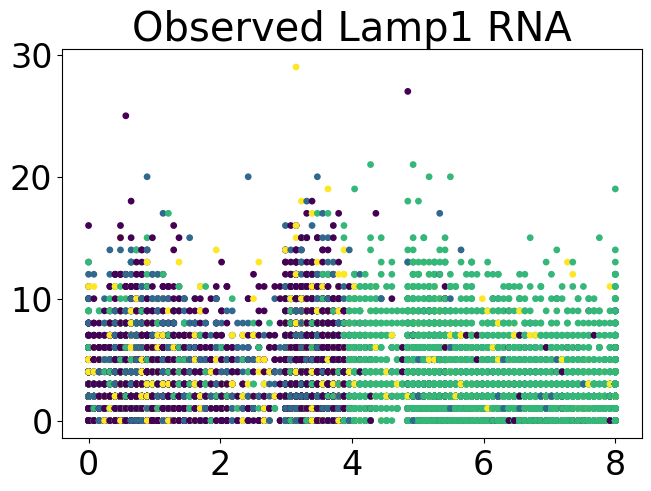

In [24]:
plt.scatter(
    t_per_cell,
    expr_RNA_ordered[gene],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} RNA");


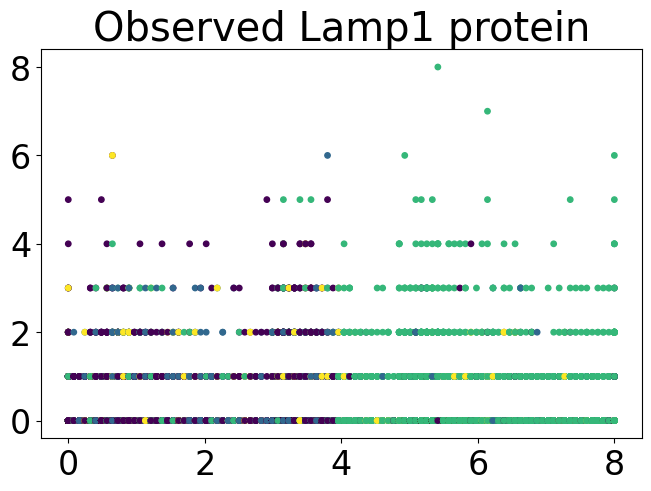

In [25]:
plt.scatter(
    t_per_cell,
    expr_ADT_ordered[prot],
    c=pd.Categorical(sampleinfo["newClustersTmp"]).codes,
    s=15
)
plt.title(f"Observed {gene} protein");

Text(0.5, 1.0, 'Imputed Lamp1 protein at each time point')

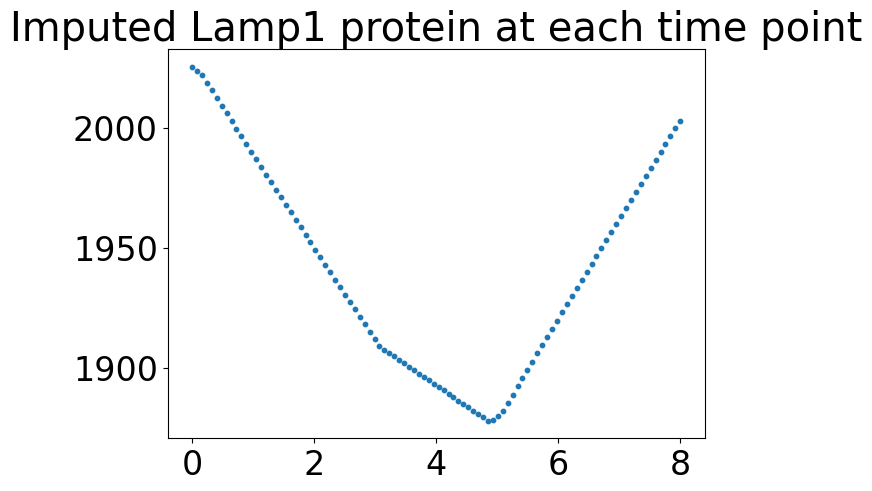

In [317]:
plt.scatter(t, P_array[:, gene_idx], s=10)
plt.title(f"Imputed {gene} protein at each time point")

Text(0.5, 1.0, 'Lamp1 RNA')

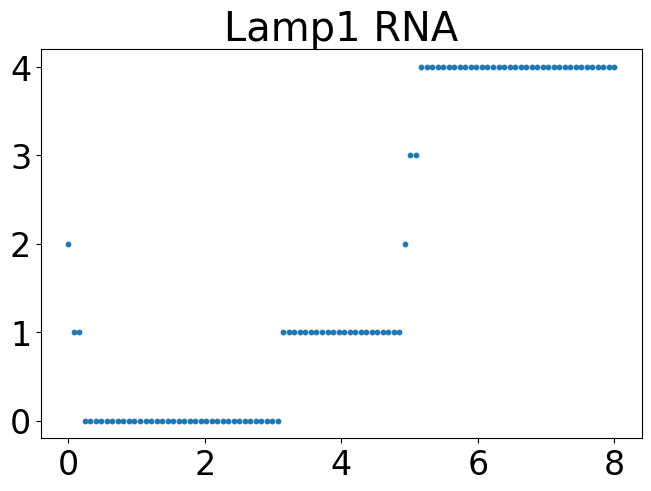

In [27]:
value = gene_order_idx[gene_idx]
X_fwd = X_fwd_per_gene[value]

states = np.asarray(states_per_gene[value])

# Get most probable state for spliced RNA at each time point
Y = states[X_fwd.argmax(axis=0)]

plt.scatter(t, Y[:, 1], s=10)
plt.title(f"{gene} RNA")

In [248]:
X_fwd.shape

(1273, 100)

In [295]:
expr_protein

,CD317
Cell_ID,
AAAGGGCTCTGAGCAT-6,201.533818
AAACCCAAGGGAGTTC-6,197.759223
AAAGGATTCACCCTCA-6,206.548704
AAAGGTATCTCTCGAC-6,206.939594
AAACGAACAACAAAGT-6,197.385674
...,...
TTTGGAGGTCTCACGG-2,209.300519
TTTGGAGTCGACGTCG-2,191.456623
TTTGGAGCACAAGTTC-2,190.392902


In [296]:
expr_ADT_subset.corrwith(expr_protein)

CD317   -0.014796
dtype: float64